# 🎬 What Makes a Movie a Blockbuster?
## Exploratory Data Analysis on TMDB Movies Dataset

**Author:** Your Name  
**Dataset:** [TMDB Movies Dataset – Kaggle](https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata)  
**Tools:** Python, Pandas, Matplotlib, Seaborn

---

### 🎯 Project Objective
This project explores what factors contribute to a movie's commercial and critical success.
We'll answer key questions like:
- Which genres earn the most revenue?
- Does a bigger budget guarantee success?
- What's the best month to release a movie?
- Do longer movies get higher ratings?

---

## 📦 Step 1: Import Libraries

In [1]:
# Core data libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Built-in utilities
import ast       # to parse string-encoded lists (genres column)
import warnings
warnings.filterwarnings('ignore')

# Make plots look clean and professional
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


## 📁 Step 2: Create Output Folders

In [2]:
import os

# Create folders if they don't exist
os.makedirs('data', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

print('✅ Folders ready: data/ and outputs/')

✅ Folders ready: data/ and outputs/


## 📂 Step 3: Load the Dataset

> **How to get the data:**
> 1. Go to https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata
> 2. Download `tmdb_5000_movies.csv`
> 3. Place it in your `data/` folder

In [3]:
# Load the CSV file
df = pd.read_csv('data/tmdb_5000_movies.csv')

# Quick peek at the data
print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(3)

Dataset shape: 4803 rows × 20 columns


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466


## 🔍 Step 4: Data Overview

In [4]:
# Column names and data types
print('📋 Column Info:')
print(df.dtypes)
print()

# Summary statistics for numeric columns
print('📊 Summary Statistics:')
df.describe()

📋 Column Info:
budget                    int64
genres                   object
homepage                 object
id                        int64
keywords                 object
original_language        object
original_title           object
overview                 object
popularity              float64
production_companies     object
production_countries     object
release_date             object
revenue                   int64
runtime                 float64
spoken_languages         object
status                   object
tagline                  object
title                    object
vote_average            float64
vote_count                int64
dtype: object

📊 Summary Statistics:


,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


In [5]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('🚨 Columns with missing values:')
print(missing_df)

🚨 Columns with missing values:
              Missing Count  Missing %
homepage               3091      64.36
tagline                 844      17.57
overview                  3       0.06
runtime                   2       0.04
release_date              1       0.02


## 🧹 Step 5: Data Cleaning

In [6]:
# --- 4.1 Keep only relevant columns ---
cols = ['title', 'genres', 'budget', 'revenue', 'runtime',
        'vote_average', 'vote_count', 'release_date', 'popularity']
df = df[cols].copy()

# --- 4.2 Parse release_date ---
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year']  = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month
df['month_name']    = df['release_date'].dt.strftime('%b')  # Jan, Feb, ...

# --- 4.3 Remove rows where budget or revenue is 0 (unreliable data) ---
df = df[(df['budget'] > 0) & (df['revenue'] > 0)]

# --- 4.4 Create profit and ROI columns ---
df['profit'] = df['revenue'] - df['budget']
df['roi']    = ((df['revenue'] - df['budget']) / df['budget'] * 100).round(2)

# --- 4.5 Parse the genres column (stored as JSON-like string) ---
def extract_genres(genre_str):
    """Convert '[{"id": 28, "name": "Action"}, ...]' → ['Action', ...]"""
    try:
        return [g['name'] for g in ast.literal_eval(genre_str)]
    except:
        return []

df['genre_list']    = df['genres'].apply(extract_genres)
df['primary_genre'] = df['genre_list'].apply(lambda x: x[0] if x else 'Unknown')

# --- 4.6 Drop rows with missing critical values ---
df.dropna(subset=['runtime', 'vote_average', 'release_date'], inplace=True)

print(f'✅ Clean dataset: {df.shape[0]} movies ready for analysis')
df.head(3)

✅ Clean dataset: 3229 movies ready for analysis


,title,genres,budget,revenue,runtime,vote_average,vote_count,release_date,popularity,release_year,release_month,month_name,profit,roi,genre_list,primary_genre
0,Avatar,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",237000000,2787965087,162.0,7.2,11800,2009-12-10,150.437577,2009.0,12.0,Dec,2550965087,1076.36,"[Action, Adventure, Fantasy, Science Fiction]",Action
1,Pirates of the Caribbean: At World's End,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",300000000,961000000,169.0,6.9,4500,2007-05-19,139.082615,2007.0,5.0,May,661000000,220.33,"[Adventure, Fantasy, Action]",Adventure
2,Spectre,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",245000000,880674609,148.0,6.3,4466,2015-10-26,107.376788,2015.0,10.0,Oct,635674609,259.46,"[Action, Adventure, Crime]",Action


---
## 📊 Step 6: Exploratory Data Analysis

### 5.1 Distribution of Key Variables

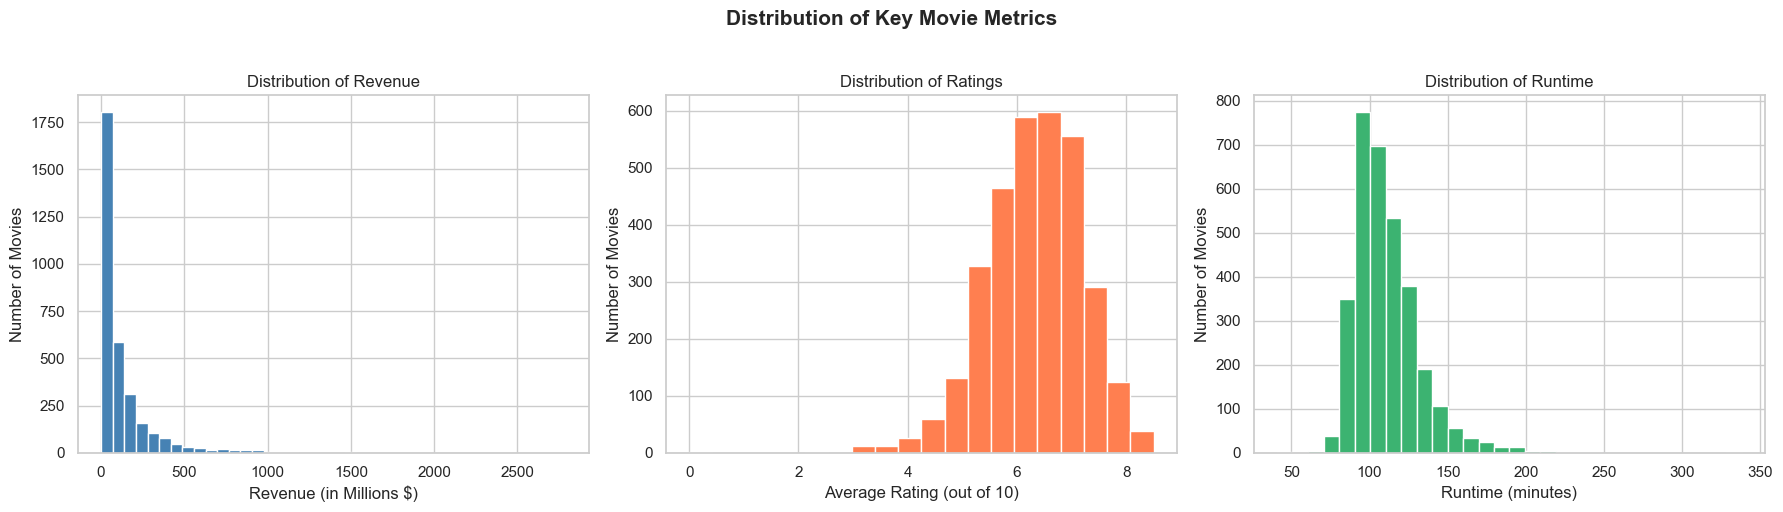

💡 Most movies earn under $200M and are rated between 5–8.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Revenue distribution
axes[0].hist(df['revenue'] / 1e6, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Revenue')
axes[0].set_xlabel('Revenue (in Millions $)')
axes[0].set_ylabel('Number of Movies')

# Ratings distribution
axes[1].hist(df['vote_average'], bins=20, color='coral', edgecolor='white')
axes[1].set_title('Distribution of Ratings')
axes[1].set_xlabel('Average Rating (out of 10)')
axes[1].set_ylabel('Number of Movies')

# Runtime distribution
axes[2].hist(df['runtime'], bins=30, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Distribution of Runtime')
axes[2].set_xlabel('Runtime (minutes)')
axes[2].set_ylabel('Number of Movies')

plt.suptitle('Distribution of Key Movie Metrics', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/01_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Most movies earn under $200M and are rated between 5–8.')

### 5.2 Which Genres Earn the Most Revenue?

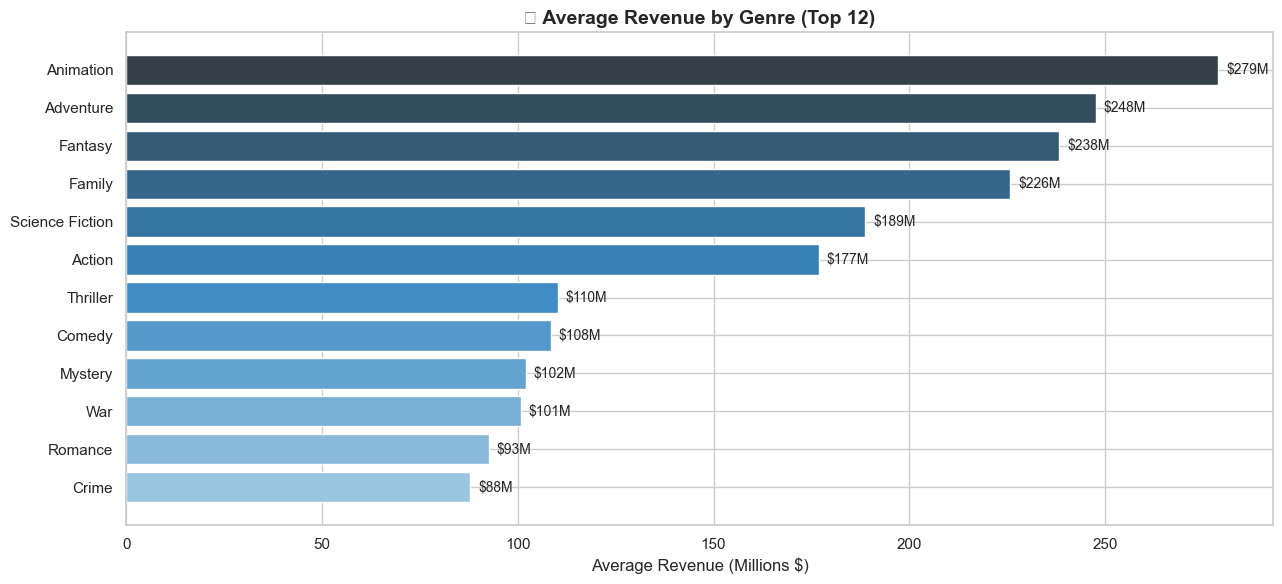

💡 Animation and Adventure genres dominate box office revenue.


In [8]:
# Explode genres so each movie-genre pair is one row
genre_df = df.explode('genre_list').rename(columns={'genre_list': 'genre'})
genre_df = genre_df[genre_df['genre'] != '']

# Average revenue by genre
genre_revenue = (
    genre_df.groupby('genre')['revenue']
    .mean()
    .sort_values(ascending=False)
    .head(12)
    / 1e6  # convert to millions
)

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(genre_revenue.index[::-1], genre_revenue.values[::-1],
               color=sns.color_palette('Blues_d', len(genre_revenue)))

# Add value labels
for bar in bars:
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'${bar.get_width():.0f}M', va='center', fontsize=10)

ax.set_xlabel('Average Revenue (Millions $)')
ax.set_title('🎬 Average Revenue by Genre (Top 12)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/02_revenue_by_genre.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Animation and Adventure genres dominate box office revenue.')

### 5.3 Does Budget Predict Revenue? (Budget vs Revenue)

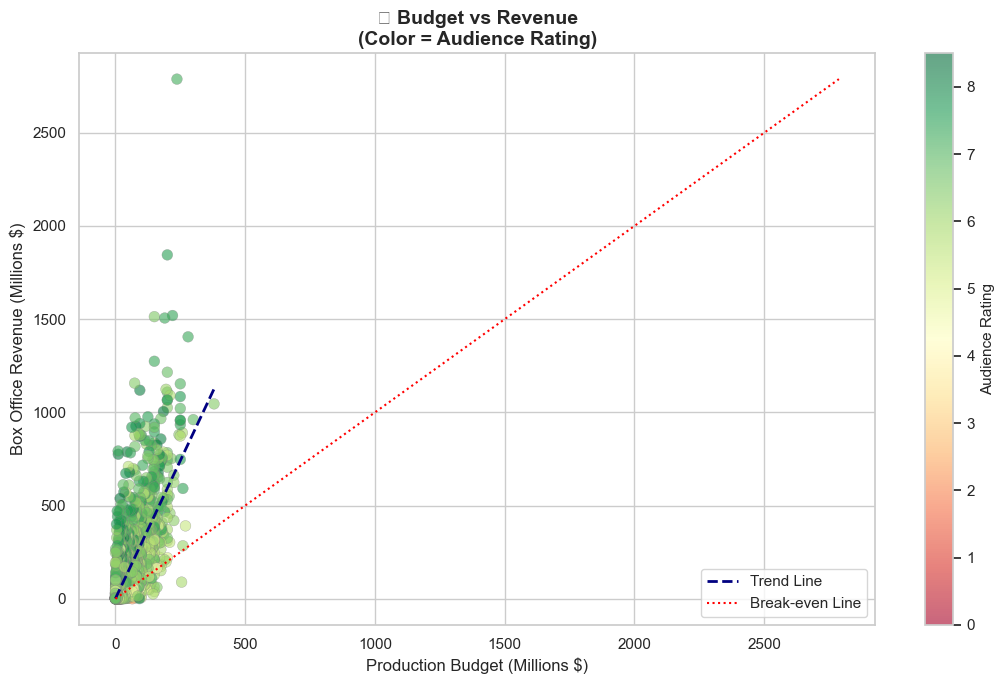

📈 Correlation between Budget and Revenue: 0.71
💡 Higher budgets tend to earn more, but many high-budget films still fall below break-even.


In [9]:
fig, ax = plt.subplots(figsize=(11, 7))

scatter = ax.scatter(
    df['budget'] / 1e6,
    df['revenue'] / 1e6,
    c=df['vote_average'],       # color by rating
    cmap='RdYlGn',
    alpha=0.6,
    s=60,
    edgecolors='gray',
    linewidths=0.3
)

# Add trend line
m, b = np.polyfit(df['budget']/1e6, df['revenue']/1e6, 1)
x_line = np.linspace(0, df['budget'].max()/1e6, 200)
ax.plot(x_line, m*x_line + b, color='navy', linewidth=2, linestyle='--', label='Trend Line')

# Break-even line (revenue = budget)
max_val = max(df['budget'].max(), df['revenue'].max()) / 1e6
ax.plot([0, max_val], [0, max_val], color='red', linewidth=1.5, linestyle=':', label='Break-even Line')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Audience Rating', fontsize=11)

ax.set_xlabel('Production Budget (Millions $)', fontsize=12)
ax.set_ylabel('Box Office Revenue (Millions $)', fontsize=12)
ax.set_title('💰 Budget vs Revenue\n(Color = Audience Rating)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('outputs/03_budget_vs_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

corr = df['budget'].corr(df['revenue'])
print(f'📈 Correlation between Budget and Revenue: {corr:.2f}')
print('💡 Higher budgets tend to earn more, but many high-budget films still fall below break-even.')

### 5.4 Best Month to Release a Movie

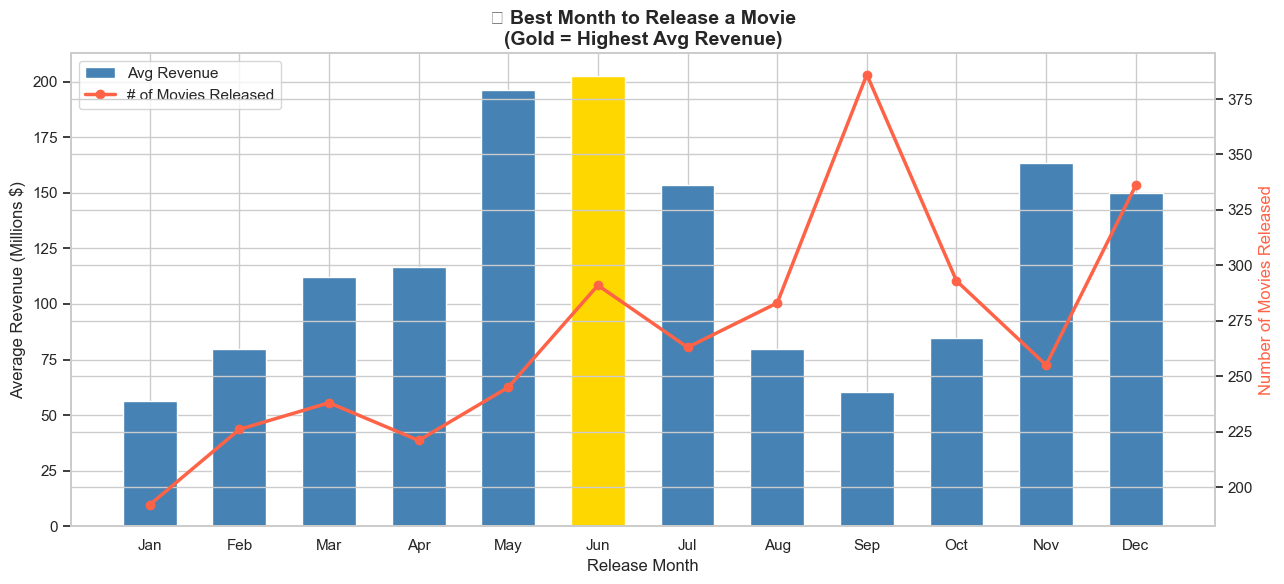

💡 Summer (May–Jul) and December are peak months for box office revenue.


In [10]:
# Month order for correct x-axis sorting
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

monthly = (
    df.groupby('month_name')
    .agg(avg_revenue=('revenue','mean'), movie_count=('title','count'))
    .reindex(month_order)
)
monthly['avg_revenue_M'] = monthly['avg_revenue'] / 1e6

fig, ax1 = plt.subplots(figsize=(13, 6))

# Bar chart for average revenue
colors = ['gold' if v == monthly['avg_revenue_M'].max() else 'steelblue'
          for v in monthly['avg_revenue_M']]
bars = ax1.bar(monthly.index, monthly['avg_revenue_M'], color=colors, width=0.6, label='Avg Revenue')
ax1.set_ylabel('Average Revenue (Millions $)', fontsize=12)
ax1.set_xlabel('Release Month', fontsize=12)

# Overlay line chart for movie count
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly['movie_count'], color='tomato', marker='o',
         linewidth=2.5, label='# of Movies Released')
ax2.set_ylabel('Number of Movies Released', fontsize=12, color='tomato')

ax1.set_title('📅 Best Month to Release a Movie\n(Gold = Highest Avg Revenue)', fontsize=14, fontweight='bold')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('outputs/04_revenue_by_month.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Summer (May–Jul) and December are peak months for box office revenue.')

### 5.5 Do Longer Movies Get Higher Ratings?

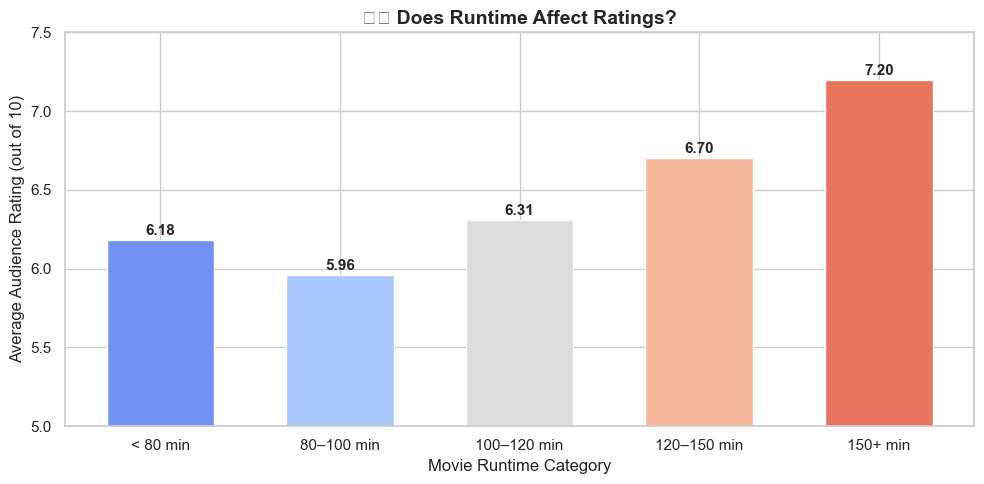

💡 Longer movies (120–150 min) tend to earn slightly higher ratings.


In [11]:
# Bin movies into runtime categories
bins   = [0, 80, 100, 120, 150, 300]
labels = ['< 80 min', '80–100 min', '100–120 min', '120–150 min', '150+ min']
df['runtime_bucket'] = pd.cut(df['runtime'], bins=bins, labels=labels)

runtime_ratings = (
    df.groupby('runtime_bucket', observed=True)['vote_average']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
palette = sns.color_palette('coolwarm', len(runtime_ratings))
bars = ax.bar(runtime_ratings['runtime_bucket'], runtime_ratings['vote_average'],
              color=palette, edgecolor='white', width=0.6)

# Add labels on bars
for bar, val in zip(bars, runtime_ratings['vote_average']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

ax.set_ylim(5, 7.5)
ax.set_xlabel('Movie Runtime Category', fontsize=12)
ax.set_ylabel('Average Audience Rating (out of 10)', fontsize=12)
ax.set_title('⏱️ Does Runtime Affect Ratings?', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/05_runtime_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Longer movies (120–150 min) tend to earn slightly higher ratings.')

### 5.6 Top 10 Most Profitable Movies

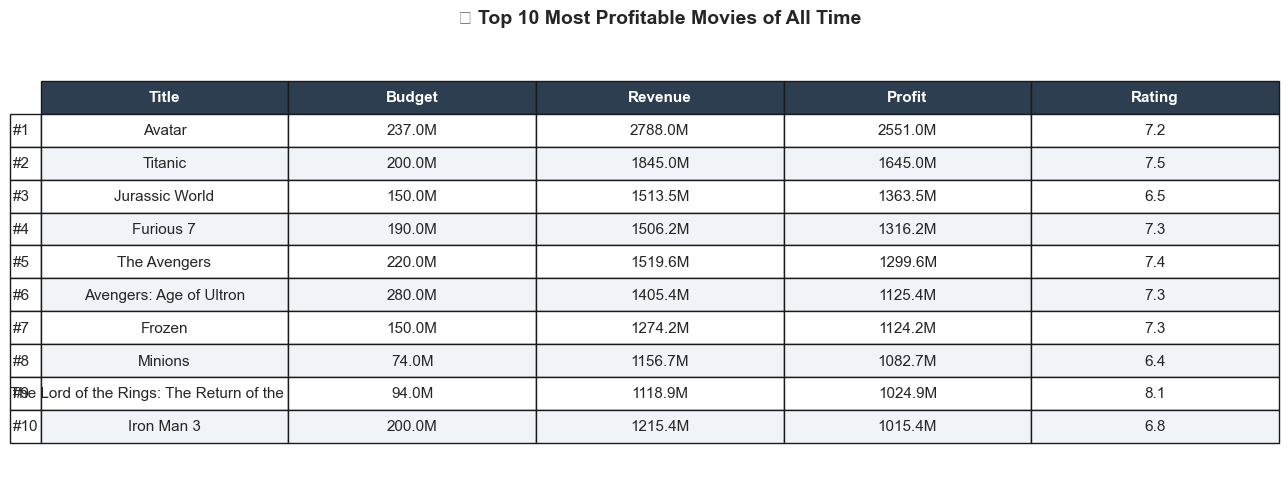

In [12]:
top10 = df.nlargest(10, 'profit')[['title', 'budget', 'revenue', 'profit', 'vote_average']]
top10 = top10.reset_index(drop=True)
top10.index += 1  # start ranking from 1

# Convert to millions for readability
for col in ['budget', 'revenue', 'profit']:
    top10[col] = (top10[col] / 1e6).round(1).astype(str) + 'M'

fig, ax = plt.subplots(figsize=(13, 5))
ax.axis('off')

table = ax.table(
    cellText=top10.values,
    colLabels=['Title', 'Budget', 'Revenue', 'Profit', 'Rating'],
    rowLabels=[f'#{i}' for i in top10.index],
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# Style header row
for j in range(len(top10.columns)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Alternate row colors
for i in range(1, len(top10)+1):
    for j in range(len(top10.columns)):
        color = '#f0f4f8' if i % 2 == 0 else 'white'
        table[i, j].set_facecolor(color)

ax.set_title('🏆 Top 10 Most Profitable Movies of All Time', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('outputs/06_top10_profitable.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.7 Correlation Heatmap

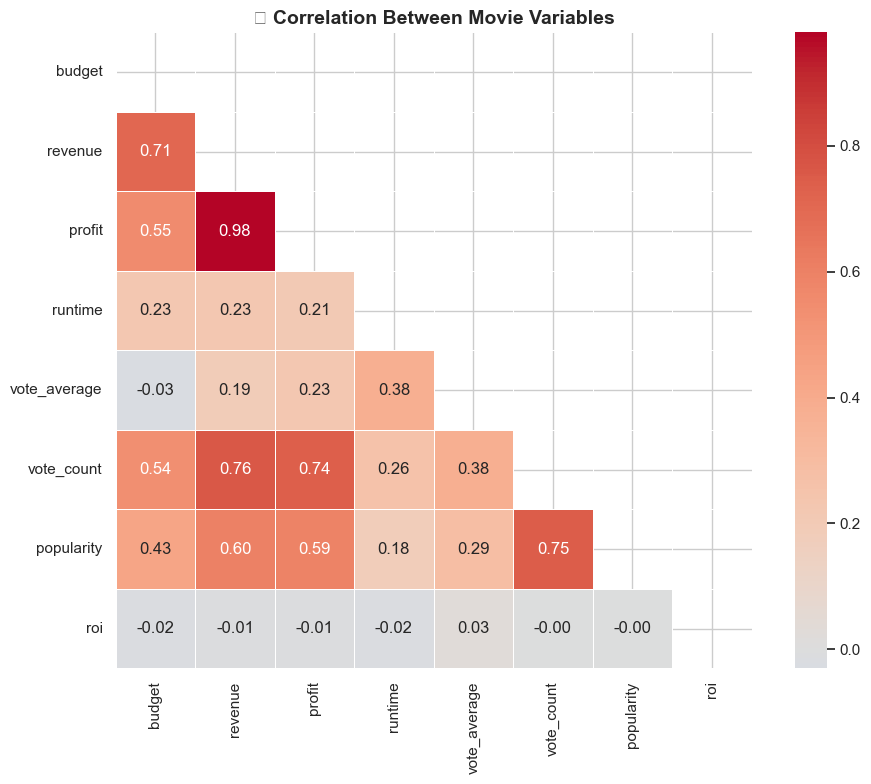

💡 Revenue and budget are highly correlated. Vote count correlates with popularity.


In [13]:
# Select numeric columns for correlation
numeric_cols = ['budget', 'revenue', 'profit', 'runtime', 'vote_average', 'vote_count', 'popularity', 'roi']
corr_matrix = df[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # show only lower triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax,
    square=True
)

ax.set_title('🔗 Correlation Between Movie Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/07_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Revenue and budget are highly correlated. Vote count correlates with popularity.')

---
## 📝 Step 7: Key Findings & Conclusions

| # | Finding | Insight |
|---|---------|--------|
| 1 | **Top Genres** | Animation, Adventure, and Fantasy earn the highest average revenue |
| 2 | **Budget vs Revenue** | Strong positive correlation (~0.73), but many big-budget films still flop |
| 3 | **Best Release Month** | May, June, July and December are peak revenue months (summer + holidays) |
| 4 | **Runtime & Ratings** | Movies in the 120–150 min range tend to earn the highest audience ratings |
| 5 | **Profitability** | A small % of films generate most of the industry's profit |

---

### 🚀 Next Steps
- Build an interactive Power BI dashboard for visual storytelling
- Try a simple ML model to predict whether a movie will be profitable